# Thin layer: Demo

Kleine Schicht zwischen **`FAIRFluidsDocument`** und Auswertung: flache `MeasurementView`-Objekte, Iteration über ein oder mehrere Dokumente, Platzhalter-Typen für spätere Arrhenius-Bundles.

**Voraussetzung:** Jupyter/VS Code mit Arbeitsverzeichnis irgendwo unter dem FAIRFluids-Repo (oder `PYTHONPATH` auf die Repo-Wurzel), damit `fairfluids` und `thin_layer` importierbar sind.

In [12]:
import sys
from pathlib import Path


def find_repo_root() -> Path:
    for d in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (d / "thin_layer" / "__init__.py").is_file() and (d / "fairfluids").is_dir():
            return d
    raise RuntimeError(
        "Repo-Wurzel nicht gefunden. Kernel neu starten mit cwd = FAIRFluids oder PYTHONPATH setzen."
    )


ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Repo:", ROOT)

Repo: /home/sga/Code/FAIRFluids


In [13]:
from thin_layer import (
    ArrheniusFitBundle,
    ArrheniusGroupKey,
    MeasurementView,
    compound_display_names,
    inspect_documents_compounds,
    inspect_views_composition,
    filter_views,
    fit_arrhenius_from_views,
    group_measurement_views_for_arrhenius,
    partition_views_for_arrhenius_plot,
    iter_measurement_views_from_documents,
    list_measurement_views_from_documents,
    load_documents_json,
    plot_arrhenius_panels_combined,
    plot_arrhenius_regression,
    scatter_arrhenius_bundles_vs_component,
    group_key_mole_fraction_or_zero,
    pred_all,
    pred_any,
    pred_composition,
    pred_extra_numeric_in_range,
    pred_fluid_component_count,
    pred_property_type_in,
)


## JSON laden

Pfade in ``JSON_PATHS`` (nächste Zelle); daraus werden validierte Dokumente gebaut. Komponenten-Labels siehe ``compound_display_names``.


In [14]:
# === Konfiguration: beliebige FAIRFluids-JSON-Pfade (Repo relativ zu ROOT) ===
JSON_PATHS = [
    #ROOT / "Workflows" / "outputs_from_spreadsheet" / "water_Cholinechloride_Glycerol.json",
    # Weitere Quellen optional:
    ROOT / "Workflows" / "outputs" / "Xu_Glycerol_Water.json",
    #ROOT / "Workflows" / "outputs" / "glycerol_water_j.jct.2014.06.031.json",
]

# Extrahierte Properties (None = alle; für Arrhenius-DES-Beispiel typisch nur Viskosität)
PROPERTY_TYPES = ["viscosity"]

DOCS = load_documents_json(*JSON_PATHS)
for i, d in enumerate(DOCS):
    print(
        f"doc[{i}]: {JSON_PATHS[i].name} | fluids={len(d.fluid)} | compounds={compound_display_names(d)}"
    )


doc[0]: Xu_Glycerol_Water.json | fluids=30 | compounds=['Choline Chloride', 'Glycerol', 'Water']


## Views aus einem oder mehreren Dokumenten

- **Ein** Dokument: ``list_measurement_views(doc, …)`` oder ``iter_measurement_views(doc, …)``.
- **Mehrere** Dokumente: ``list_measurement_views_from_documents(DOCS, …)`` (einzelnes Dokument geht auch).
- ``PROPERTY_TYPES`` steuert, welche Messungen erscheinen (muss zur Datei passen).


In [15]:
all_views = list_measurement_views_from_documents(
    DOCS,
    property_types=PROPERTY_TYPES,
)
print("Messungen (Views):", len(all_views))

v0 = all_views[0]
print("\nErstes Beispiel (MeasurementView):")
print("  document_index:", v0.document_index)
print("  fluid_index:   ", v0.fluid_index)
print("  measurement_id:", v0.measurement_id)
print("  source_doi:    ", v0.source_doi)
print("  property_type: ", v0.property_type)
print("  property_value:", v0.property_value)
print("  temperature:   ", v0.temperature, "K")
print("  fluid_compounds:", v0.fluid_compounds)
print("  mole_fractions: ", v0.mole_fractions)
print("  uncertainty:   ", v0.uncertainty)
print("  extra_parameters (Auszug):", list(v0.extra_parameters.keys())[:12], "…")


Messungen (Views): 267

Erstes Beispiel (MeasurementView):
  document_index: 0
  fluid_index:    0
  measurement_id: 92ea827b-94b9-413f-a6c5-0c534aa756b0
  source_doi:     10.1016/j.aca.2012.12.019
  property_type:  viscosity
  property_value: 0.060200000000000004
  temperature:    313.15 K
  fluid_compounds: ['Choline Chloride', 'Glycerol', 'Water']
  mole_fractions:  [0.250078162333, 0.500156324667, 0.249765513]
  uncertainty:    None
  extra_parameters (Auszug): ['Mole fraction', 'Temperature', 'Solvent: Amount ratio of component to other component of binary solvent'] …


## Mehrere Dokumente — `document_index` unterscheidet die Quelle

Hier absichtlich **dieselbe** Datei zweimal in einer Liste (nur Demo des Index).

In [16]:
multi = list_measurement_views_from_documents(DOCS, property_types=PROPERTY_TYPES)
print("Gesamt Views:", len(multi))
from collections import Counter

print("document_index:", Counter(v.document_index for v in multi))


Gesamt Views: 267
document_index: Counter({0: 267})


## Platzhalter: `ArrheniusGroupKey` & `ArrheniusFitBundle`

Später mit echten Fit-Ergebnissen und `measurement_ids` aus den Views füllen.

## Arrhenius: Gruppierung, Fit und Plot

- **`all_views`** enthält alle Messungen für die gewählten `PROPERTY_TYPES`.
- **Gruppe** = gleiche `source_doi` + gleiche Komponenten-Reihenfolge (normalisierte Namen) + gleiche (gerundete) `mole_fractions`. Pro Gruppe ein Scatter + optional eine Regressionsgerade.
- **`ArrheniusGroupKey`** speichert `fluid_compounds` und `mole_fractions` **parallel** (wie in `MeasurementView`), z. B. für Plots $E_a$ vs. Wasser-Molanteil.
- **`group_key_mole_fraction_or_zero`**: fehlt eine Komponente in der Gruppe (z. B. binäres DES ohne Wasser), liefert der Molanteil für diese Komponente **`0.0`** — sinnvoll, wenn ternäre und binäre Messreihen dieselbe x-Achse nutzen.
- **Legenden:** ``plot_arrhenius_regression(..., show_legend=True)`` — DOI-Farben + ggf. „zu wenig Punkte“ / Waisen; ``plot_arrhenius_panels_combined`` — Panel-Marker und optional zweite Legende ``DOI (Farbe)``; ``scatter_arrhenius_bundles_vs_component`` — bei ``color_by`` ``doi`` / ``uniform``.
- **`scatter_arrhenius_bundles_vs_component`**: Scatter $E_a$ oder $\ln A_s$ vs. Molanteil; **y-Fehlerbalken** optional; **Farben**: ``color_by='doi'`` (Hash-Farben), ``'uniform'``, ``'component'`` (hellgrau→Blau nach x-Molanteil, optional Colorbar).
- **Keine Gerade**, wenn eine Gruppe weniger als `min_points` (z. B. 2) Temperaturen hat — die Punkte erscheinen trotzdem (grau).
- **Rote Dreiecke** (Legende): Messungen mit gültigem T und η, aber **ohne vollständige Molbrüche** für den Gruppenschlüssel (falls vorhanden).
- **`ArrheniusFitBundle`**: enthält u. a. ``Ea_J_mol_std``, ``lnAs_std``, ``As`` / ``As_std`` (OLS-Kovarianz wie ``fit_arrhenius`` im Hauptpaket); optional ``plot_measurement_uncertainty=True`` in ``plot_arrhenius_regression`` für y-Fehlerbalken aus ``MeasurementView.uncertainty``.
- **`fit_arrhenius_from_views`** / `bundles`: nur Gruppen mit genug Punkten für einen Fit.

- `partition_views_for_arrhenius_plot` — gruppierte Punkte, „Waisen“, und wie viele Views gar nicht plottbar sind (fehlendes T/η).
- `plot_arrhenius_regression(..., print_coverage=True)` — kurze Statistik in der Konsole.



[Arrhenius-Plot] Eingabe-Views: 267 | im Plot (gruppiert): 267 | ohne Molbruch-Schlüssel: 0 | ohne T/η/Property-Filter: 0


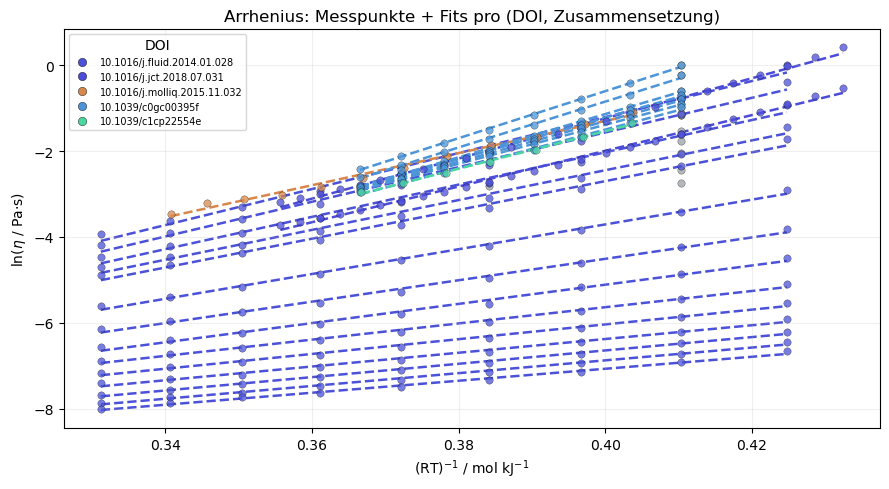

In [17]:
import matplotlib.pyplot as plt

groups = group_measurement_views_for_arrhenius(all_views, property_type="viscosity")
#print("Anzahl Gruppen (DOI + Molbrüche):", len(groups))

#_, orphans, skipped = partition_views_for_arrhenius_plot(all_views, property_type="viscosity")
#n_pts_in_groups = sum(len(pts) for pts in groups.values())
#print(
#    "Punkte in Gruppen:", n_pts_in_groups,
#    "| all_views:", len(all_views),
#    "| Waisen (ohne Molbruch-Schlüssel):", len(orphans),
#    "| ohne T/η (übersprungen):", skipped,
#)

bundles = fit_arrhenius_from_views(all_views, property_type="viscosity", min_points=2)
#print("Erfolgreiche Fits (≥2 Punkte):", len(bundles))
#for i, b in enumerate(bundles):
#    print(
#        f"[{i}] DOI={b.group_key.source_doi!r} | x={b.group_key.mole_fractions} | "
#        f"Ea={round(b.Ea_J_mol)} J/mol | n_pts={b.n_points} | R²={b.R_squared} | "
#        f"n_ids={len(b.measurement_ids)}"
#    )

fig, ax, bundles_plot = plot_arrhenius_regression(
    all_views,
    property_type="viscosity",
    min_points=2,
    figsize=(9, 5),
    title="Arrhenius: Messpunkte + Fits pro (DOI, Zusammensetzung)",
    print_coverage=True,
)
assert len(bundles_plot) == len(bundles)
plt.show()


## Nur Messpunkte (ohne Gruppierung / ohne Regression)

ln(η) vs. 1000/(RT) — gleiche x-Achse wie oben, aber alle Punkte in einer Farbe.

## Zusammensetzungs-Filter + Arrhenius (mehrere Panels)

1. **Mit Wasser** — jede Messung mit Wasser-Molanteil > 0 (inkl. reines Wasser).  
2. **Nur DES ChCl:Gly = 1:2** — binär Glycerol + Cholinchlorid, ohne Wasser; Molratio **ChCl : Gly ≈ 1 : 2** (wie üblich bei „1:2“-Deep Eutectic Solvent).  
3. **Wasser + DES 1:2** — Wasser dazu, dieselbe ChCl:Gly-Ratio unter den beiden anderen Komponenten.

**Plots (beides nutzt dieselben `PANEL_SPECS`):**

- **Eine Achse:** nächste Code-Zelle — `plot_arrhenius_panels_combined` (Marker = Panel, Farbe = Fit-Gruppe).  
- **Separate Teilgrafiken:** darauf folgende Zelle — je Panel eine eigene y-Achse mit `plot_arrhenius_regression`.


In [18]:
# === Komponenten-Überblick (Schema + Messungen) ===
import pprint

pprint.pp(inspect_documents_compounds(DOCS))
pprint.pp(inspect_views_composition(all_views))

# === Filter-Panels: Teilstrings wie in der Ausgabe oben (fluid_compound_labels) ===
# "des_gly_chol": Beispiel ChCl–Glycerol–Wasser — nur über pred_composition + pred_all
# "pure_water": nahezu reines Wasser (x_w hoch) oder nur-Wasser-Fluid (eine Komponente)
# "jct2019_mass_bins": Massenanteil-Bins (extra_parameters)

PANEL_SCENARIO = "des_gly_chol"
ARRHENIUS_PROPERTY = "viscosity"

# Kurzbezeichner: Tupel von Teilstrings pro Komponente (case-insensitive, Reihenfolge egal)
W = ("water",)
CHOL = ("choline",)
GLY = ("glycerol",)
# Zielratio Zähler/Nenner (hier: x_ChCl / x_Gly ≈ 1/2 wie üblich DES 1:2)
DES_RATIO_CHOL_PER_GLY = 0.5
RATIO_TOL = 0.01

if PANEL_SCENARIO == "des_gly_chol":
    base = filter_views(all_views, pred_property_type_in(ARRHENIUS_PROPERTY))
    XW_PURE = 1.0 - 1e-4
    PANEL_SPECS = [
        (
            "Binary DES ChCl:Gly 1:2 ",
            filter_views(
                base,
                pred_all(
                    pred_composition(n_fluid_components=2),
                    pred_composition(
                        mole_ratio=(CHOL, GLY, DES_RATIO_CHOL_PER_GLY),
                        mole_ratio_tol=RATIO_TOL,
                    ),
                    pred_composition(exclude_min_mole_fractions=[(W, 1e-8)]),
                ),
            ),
        ),
        (
            "Ternary + DES 1:2 + Water",
            filter_views(
                base,
                pred_all(
                    pred_composition(min_mole_fractions=[(W, 0)]),
                    pred_composition(
                        mole_ratio=(CHOL, GLY, DES_RATIO_CHOL_PER_GLY),
                        mole_ratio_tol=RATIO_TOL,
                    ),
                ),
            ),
        ),
        (
            "Pure Water",
            filter_views(
                base,
                pred_any(
                    pred_composition(min_mole_fractions=[(W, XW_PURE)]),
                    pred_all(
                        pred_fluid_component_count(1),
                        lambda v: any("water" in str(c).lower() for c in v.fluid_compounds),
                    ),
                ),
            ),
        ),
    ]
else:
    raise ValueError(f"Unbekanntes PANEL_SCENARIO: {PANEL_SCENARIO!r}")

for title, subset in PANEL_SPECS:
    print(f"{title}: {len(subset)}")


[{'document_index': 0, 'compounds': ['Choline Chloride', 'Glycerol', 'Water']}]
{'n_views': 267,
 'fluid_compound_labels': ['Choline Chloride', 'Glycerol', 'Water'],
 'extra_parameter_keys': ['Mole fraction',
                          'Solvent: Amount ratio of component to other '
                          'component of binary solvent',
                          'Temperature'],
 'property_types': ['viscosity']}
Binary DES ChCl:Gly 1:2 : 62
Ternary + DES 1:2 + Water: 142
Pure Water: 9


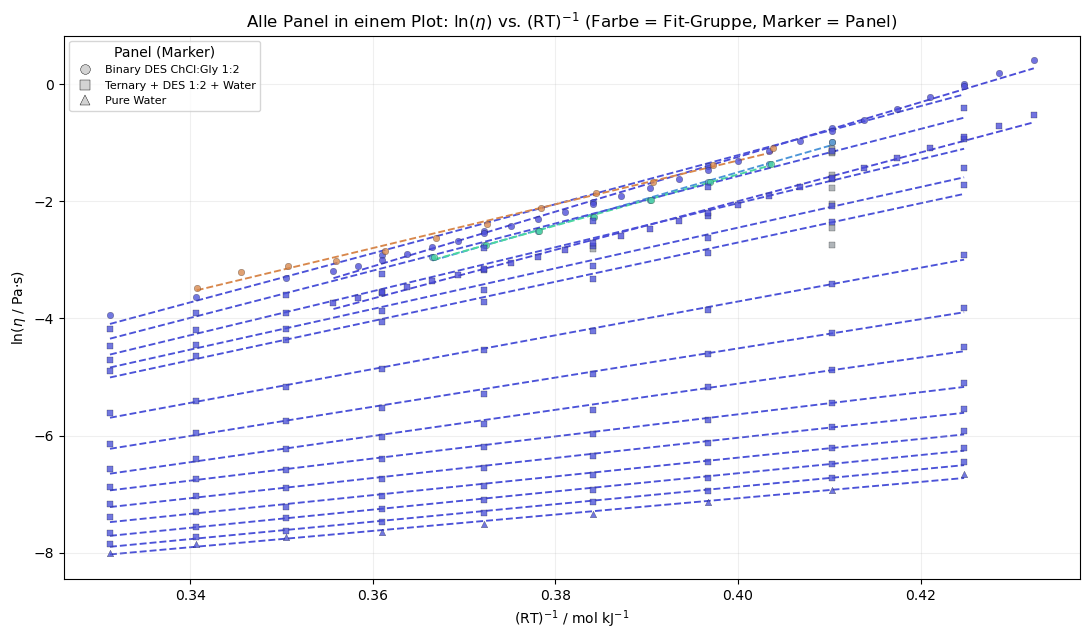

Fits pro Panel: [5, 13, 1]
Alle Bundles:
Bundle 1:
ArrheniusFitBundle(group_key=ArrheniusGroupKey(source_doi='10.1016/j.fluid.2014.01.028', fluid_compounds=('Choline Chloride', 'Glycerol'), mole_fractions=(0.333333, 0.666667)), Ea_J_mol=41927.868165286935, lnAs=-17.9791904035712, n_points=9, measurement_ids=('1d55e3f0-22bf-46e6-8c74-7ffc86d17eff', '0df634de-d29c-4ee1-ae8e-640df822fea1', 'dbc31903-bc57-4a43-8450-67756c212a20', 'be7d5147-4d7e-48e9-aba9-9a2a1847779b', '6dfa959c-fa47-4158-9cb4-dccfba171943', 'ddbf8b02-2bc7-4897-963a-17270fd50d18', '4237857b-a2b0-467e-8864-0c355f961007', '0f023a6b-26af-4a9e-8134-f0474587782c', '50cf14f5-496a-4fb1-be6f-c0bbf8ce6854'), R_squared=0.9926221647938495, T_min_K=283.15, T_max_K=363.15, As=1.5550230060063858e-08, Ea_J_mol_std=1366.237659016825, Ea_kJ_mol_std=1.366237659016825, lnAs_std=0.5134353262679956, As_std=7.98403744443128e-09, viscosity_uncertainty_mean=0.0011528552222222221, meta={'slope': 41927.868165286935, 'intercept': -17.9791904035712, 

In [19]:
import matplotlib.pyplot as plt

# Alle Panel in einer Achse (Marker = Panel, Farbe = Fit-Gruppe über alle Panels)
fig, ax, all_bundles = plot_arrhenius_panels_combined(
    PANEL_SPECS,
    property_type=ARRHENIUS_PROPERTY,
    min_points=2,
)

plt.show()

print("Fits pro Panel:", [len(b) for b in all_bundles])

print("Alle Bundles:")
for idx, bundle in enumerate(all_bundles):
    print(f"Bundle {idx+1}:")
    for x in bundle:
        print(x)


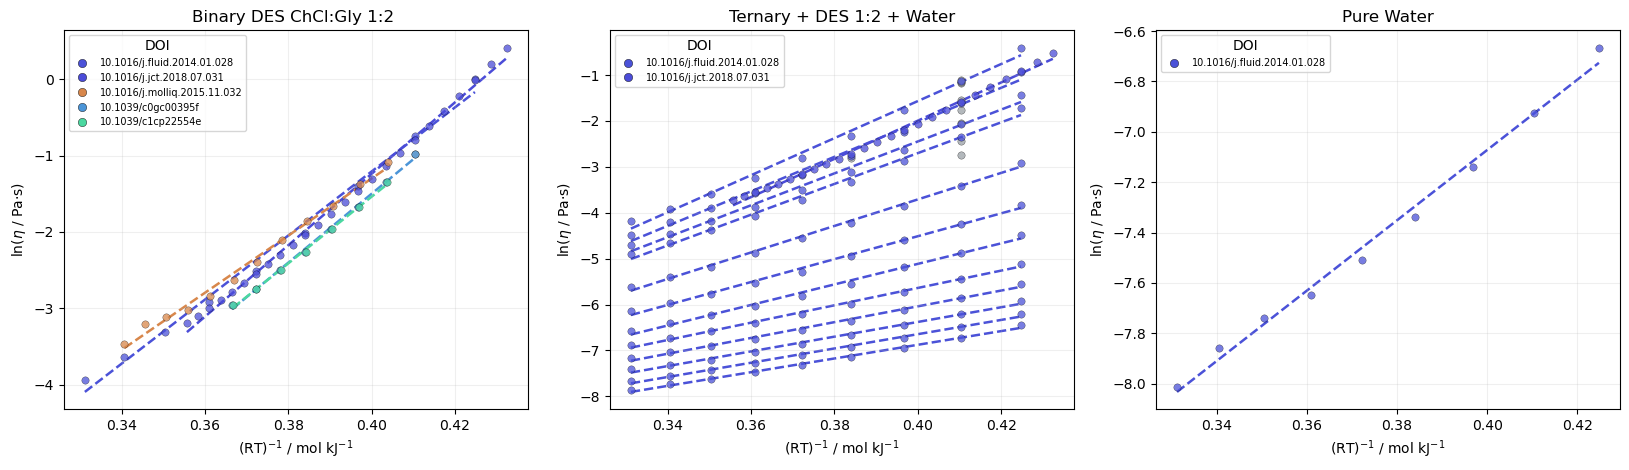

Fits pro Panel: [5, 13, 1]
Alle Bundles:
Bundle 1:
ArrheniusFitBundle(group_key=ArrheniusGroupKey(source_doi='10.1016/j.fluid.2014.01.028', fluid_compounds=('Choline Chloride', 'Glycerol'), mole_fractions=(0.333333, 0.666667)), Ea_J_mol=41927.868165286935, lnAs=-17.9791904035712, n_points=9, measurement_ids=('1d55e3f0-22bf-46e6-8c74-7ffc86d17eff', '0df634de-d29c-4ee1-ae8e-640df822fea1', 'dbc31903-bc57-4a43-8450-67756c212a20', 'be7d5147-4d7e-48e9-aba9-9a2a1847779b', '6dfa959c-fa47-4158-9cb4-dccfba171943', 'ddbf8b02-2bc7-4897-963a-17270fd50d18', '4237857b-a2b0-467e-8864-0c355f961007', '0f023a6b-26af-4a9e-8134-f0474587782c', '50cf14f5-496a-4fb1-be6f-c0bbf8ce6854'), R_squared=0.9926221647938495, T_min_K=283.15, T_max_K=363.15, As=1.5550230060063858e-08, Ea_J_mol_std=1366.237659016825, Ea_kJ_mol_std=1.366237659016825, lnAs_std=0.5134353262679956, As_std=7.98403744443128e-09, viscosity_uncertainty_mean=0.0011528552222222221, meta={'slope': 41927.868165286935, 'intercept': -17.9791904035712, 

In [20]:
# Separate Ansicht: je Panel eine eigene Teilgrafik (plot_arrhenius_regression)
import matplotlib.pyplot as plt

_n = max(1, len(PANEL_SPECS))
fig, ax_row = plt.subplots(1, _n, figsize=(4.8 * _n + 2, 4.8), sharey=False)
axes = list(ax_row) if _n > 1 else [ax_row]

all_bundles = []
for ax, (title, subset) in zip(axes, PANEL_SPECS):
    if not subset:
        ax.set_title(title + " (leer)")
        ax.text(0.5, 0.5, "keine Daten", ha="center", va="center", transform=ax.transAxes)
        all_bundles.append([])
        continue
    _, _, bundles = plot_arrhenius_regression(
        subset,
        ax=ax,
        property_type=ARRHENIUS_PROPERTY,
        min_points=2,
        title=title,
    )
    all_bundles.append(bundles)

plt.tight_layout()
plt.show()

print("Fits pro Panel:", [len(b) for b in all_bundles])

print("Alle Bundles:")
for idx, bundle in enumerate(all_bundles):
    print(f"Bundle {idx+1}:")
    for x in bundle:
        print(x)


In [21]:
key = ArrheniusGroupKey(
    source_doi="10.1016/j.example.2024.01.001",
    fluid_compounds=("Water", "Choline Chloride", "Glycerol"),
    mole_fractions=(0.25, 0.50, 0.25),
)
bundle = ArrheniusFitBundle(
    group_key=key,
    Ea_J_mol=42_000.0,
    lnAs=-4.2,
    n_points=12,
    measurement_ids=("uuid-1", "uuid-2"),
    R_squared=0.991,
    T_min_K=273.15,
    T_max_K=353.15,
    meta={"fit_engine": "demo"},
)
bundle


ArrheniusFitBundle(group_key=ArrheniusGroupKey(source_doi='10.1016/j.example.2024.01.001', fluid_compounds=('Water', 'Choline Chloride', 'Glycerol'), mole_fractions=(0.25, 0.5, 0.25)), Ea_J_mol=42000.0, lnAs=-4.2, n_points=12, measurement_ids=('uuid-1', 'uuid-2'), R_squared=0.991, T_min_K=273.15, T_max_K=353.15, As=None, Ea_J_mol_std=None, Ea_kJ_mol_std=None, lnAs_std=None, As_std=None, viscosity_uncertainty_mean=None, meta={'fit_engine': 'demo'})

## $E_a$ vs. Wasser-Molanteil

Alle Arrhenius-Fits aus den Panel-Zellen oben (``all_bundles``), x-Achse = Wasser-Molanteil; fehlt Wasser in der Gruppe (binäres DES), wird **0** verwendet — siehe ``group_key_mole_fraction_or_zero``.


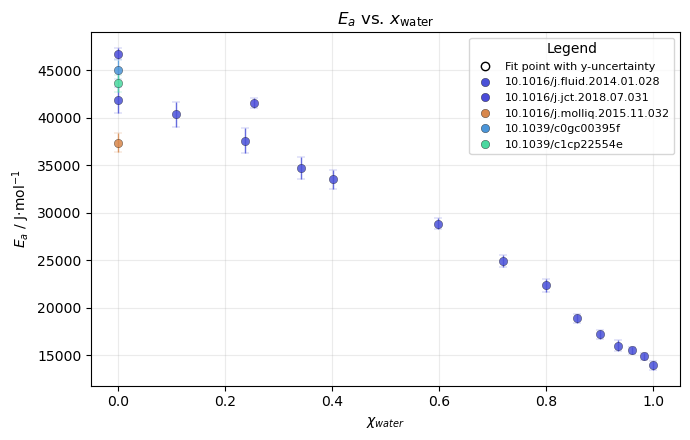

Anzahl Fits im Scatter: 19


In [23]:
import matplotlib.pyplot as plt

try:
    panels = all_bundles
except NameError:
    panels = []
    print("Hinweis: Zuerst eine der Panel-Plot-Zellen ausführen, die `all_bundles` setzt.")

flat_bundles = [b for panel in panels for b in panel]
if not flat_bundles:
    print("Keine Bundles zum Plotten.")
else:
    fig, ax = scatter_arrhenius_bundles_vs_component(
        flat_bundles,
        component_substrings=("water",),
        show_legend=True,
        color_by="doi",
        y_field="Ea_J_mol",
        fill_missing_component_with_zero=True,
        title=r"$E_a$ vs. $x_\mathrm{water}$",
    )
    plt.show()
    print("Anzahl Fits im Scatter:", len(flat_bundles))
